# Этап 2.


- сравнить графики сходимости со стадией 1;
- реализовать подстановку в исходной системе;
- учесть, что после подстановки максимальный порядок производной равен 2;
- добавить граничные условия для `v`;
- сравнить 3 варианта архитектуры:
  1. одна сеть с двумя выходами `[u, v]`;
  2. две отдельные сети;
  3. общие слои + раздельные головы.

Идея шаблона: вы сами дописываете формулы, а все основные блоки уже разложены по местам.

In [ ]:
import platform
print(platform.processor())

Intel64 Family 6 Model 140 Stepping 1, GenuineIntel


In [ ]:
import itertools
import json
import math
import re
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


## 1. Общие настройки

In [ ]:
PREFER_ACCELERATOR = True
CPU_DTYPE = torch.float64
ACCELERATOR_DTYPE = torch.float32


def detect_training_device():
    if PREFER_ACCELERATOR:
        if torch.cuda.is_available():
            return torch.device('cuda'), 'CUDA'
        if hasattr(torch, 'xpu') and torch.xpu.is_available():
            return torch.device('xpu'), 'XPU'
        if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
            return torch.device('mps'), 'MPS'
    return torch.device('cpu'), 'CPU'


def describe_device(device):
    if device.type == 'cuda':
        return torch.cuda.get_device_name(device.index or 0)
    if device.type == 'xpu' and hasattr(torch, 'xpu') and hasattr(torch.xpu, 'get_device_name'):
        return torch.xpu.get_device_name(device.index or 0)
    return str(device)


DEVICE, DEVICE_KIND = detect_training_device()
DEVICE_NAME = describe_device(DEVICE)
DTYPE = ACCELERATOR_DTYPE if DEVICE.type != 'cpu' else CPU_DTYPE
torch.set_default_dtype(DTYPE)

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('training device:', DEVICE)
print('device kind:', DEVICE_KIND)
print('device name:', DEVICE_NAME)
print('float type:', DTYPE)
print('seed:', SEED)
if DEVICE.type == 'cpu':
    print('note: current PyTorch runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible PyTorch build.')


training device: cpu
device kind: CPU
device name: cpu
float type: torch.float64
seed: 1234
note: current PyTorch runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible PyTorch build.


## 2. Параметры задачи

Здесь оставьте ваши реальные значения области, размеров выборок, коэффициентов уравнения и весов лосса.

In [ ]:
# ??????? ? ??????? ??????? ????? ?? ??????? ???? 1
tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0

N_0 = 300
N_r = 20000
N_b = 2000

b = torch.tensor(5.0, dtype=DTYPE, device=DEVICE)
k = torch.tensor(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE, device=DEVICE)
c = torch.tensor((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE, device=DEVICE)
x0 = torch.tensor(-12.0, dtype=DTYPE, device=DEVICE)
us = torch.tensor(10.0, dtype=DTYPE, device=DEVICE)


NUM_HIDDEN_LAYERS = 4
NUM_SHARED_LAYERS = 4
HIDDEN_DIM = 64
NUM_FOURIER = 16
ACTIVATION = 'tanh'
LEARNING_RATE = 2e-4
NUM_STEPS = 3000
PRINT_EVERY = 100
PLOT_EVERY = 2000
PLOT_NUM_X = 256

lambda_r = torch.tensor(1.0, dtype=DTYPE, device=DEVICE)
lambda_b = torch.tensor(1.0, dtype=DTYPE, device=DEVICE)
lambda_0 = torch.tensor(1.0, dtype=DTYPE, device=DEVICE)

lb = torch.tensor([tmin, xmin], dtype=DTYPE, device=DEVICE)
ub = torch.tensor([tmax, xmax], dtype=DTYPE, device=DEVICE)

print('Training config:')
print('  hidden_layers =', NUM_HIDDEN_LAYERS)
print('  shared_layers =', NUM_SHARED_LAYERS)
print('  hidden_dim =', HIDDEN_DIM)
print('  num_fourier =', NUM_FOURIER)
print('  learning_rate =', LEARNING_RATE)
print('  num_steps =', NUM_STEPS)
print('  print_every =', PRINT_EVERY)
print('  plot_every =', PLOT_EVERY)


Training config:
  hidden_layers = 4
  shared_layers = 4
  hidden_dim = 64
  num_fourier = 16
  learning_rate = 0.0002
  num_steps = 3000
  print_every = 100
  plot_every = 2000


## 3. Точное решение и подстановка

Если точное решение известно, заполните обе функции. Если точного решения для `v` нет в явном виде, можно выразить его через подстановку.

In [ ]:
def differentiate(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
    )[0]


def u_exact(t, x):
    t = torch.as_tensor(t, dtype=DTYPE, device=DEVICE)
    x = torch.as_tensor(x, dtype=DTYPE, device=DEVICE)
    z = k * (x - b * t - x0)
    th = torch.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


def v_exact(t, x):
    t = torch.as_tensor(t, dtype=DTYPE, device=DEVICE)
    x = torch.as_tensor(x, dtype=DTYPE, device=DEVICE)
    x_req = x.clone().detach().requires_grad_(True)
    u = u_exact(t, x_req)
    u_x = differentiate(u, x_req)
    v = differentiate(u_x, x_req)
    return v


def u0(x):
    return u_exact(torch.zeros_like(x, dtype=DTYPE, device=x.device), x).detach()


def v0(x):
    return v_exact(torch.zeros_like(x, dtype=DTYPE, device=x.device), x).detach()


## 4. Генерация обучающих точек

Здесь строятся:
- точки начального условия;
- внутренние коллокационные точки;
- граничные точки слева и справа.

In [ ]:
t_0 = torch.zeros((N_0, 1), dtype=DTYPE, device=DEVICE)
x_0 = lb[1] + (ub[1] - lb[1]) * torch.rand((N_0, 1), dtype=DTYPE, device=DEVICE)
X_0 = torch.cat([t_0, x_0], dim=1)

u_0 = u0(x_0)
v_0 = v0(x_0)

t_r = (lb[0] + 1e-6) + (ub[0] - (lb[0] + 1e-6)) * torch.rand((N_r, 1), dtype=DTYPE, device=DEVICE)
x_r = lb[1] + (ub[1] - lb[1]) * torch.rand((N_r, 1), dtype=DTYPE, device=DEVICE)
X_r = torch.cat([t_r, x_r], dim=1)

t_b = lb[0] + (ub[0] - lb[0]) * torch.rand((N_b, 1), dtype=DTYPE, device=DEVICE)
x_lb = torch.ones((N_b, 1), dtype=DTYPE, device=DEVICE) * lb[1]
x_ub = torch.ones((N_b, 1), dtype=DTYPE, device=DEVICE) * ub[1]
X_lb = torch.cat([t_b, x_lb], dim=1)
X_ub = torch.cat([t_b, x_ub], dim=1)

print('X_0:', tuple(X_0.shape))
print('X_r:', tuple(X_r.shape))
print('X_lb:', tuple(X_lb.shape), 'X_ub:', tuple(X_ub.shape))


X_0: (300, 2)
X_r: (20000, 2)
X_lb: (2000, 2) X_ub: (2000, 2)


## 5. Вспомогательные функции

Эти функции общие для всех трех архитектур.

Фурие

In [ ]:
FOURIER_BACKEND = 'pytorch'
print('Using PyTorch Fourier features.')


class FourierFeatureProjection(nn.Module):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False):
        super().__init__()
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

        generator = torch.Generator(device='cpu')
        generator.manual_seed(self.seed)
        B = torch.randn(
            (1, self.gaussian_projection),
            generator=generator,
            dtype=CPU_DTYPE,
        ) * self.gaussian_scale

        if self.trainable_projection:
            self.B = nn.Parameter(B)
        else:
            self.register_buffer('B', B)

    def forward(self, x):
        x = x.to(dtype=self.B.dtype, device=self.B.device)
        projection = 2.0 * math.pi * (x @ self.B)
        return torch.cat([torch.sin(projection), torch.cos(projection)], dim=-1)


Using PyTorch Fourier features.


In [ ]:
def stack_tx(t, x):
    return torch.cat([t, x], dim=1)


def split_uv(y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    return u, v


def mse(x):
    return torch.mean(x.square())


def make_activation(activation='tanh'):
    name = activation.lower()
    if name == 'tanh':
        return nn.Tanh()
    if name == 'relu':
        return nn.ReLU()
    if name == 'gelu':
        return nn.GELU()
    if name == 'sigmoid':
        return nn.Sigmoid()
    raise ValueError(f'Unsupported activation: {activation}')


def make_hidden_layers(input_dim, num_hidden_layers=4, hidden_dim=64):
    layers = nn.ModuleList()
    current_dim = input_dim
    for _ in range(num_hidden_layers):
        layers.append(nn.Linear(current_dim, hidden_dim))
        current_dim = hidden_dim
    return layers, current_dim


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    return FourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


## 6. Вариант 1: одна сеть с двумя выходами

In [ ]:
class TwoOutputPINN(nn.Module):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        feature_dim = 4 * num_fourier
        self.hidden_layers, last_dim = make_hidden_layers(feature_dim, num_hidden_layers, hidden_dim)
        self.activation = make_activation(activation)
        self.output_layer = nn.Linear(last_dim, 2)

    def forward(self, inputs):
        inputs = inputs.to(dtype=DTYPE, device=DEVICE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = self.t_proj(t).to(dtype=DTYPE)
        x_features = self.x_proj(x).to(dtype=DTYPE)
        features = torch.cat([t_features, x_features], dim=1)

        h = features
        for layer in self.hidden_layers:
            h = self.activation(layer(h))
        return self.output_layer(h)


## 7. Вариант 2: две отдельные сети

In [ ]:
class SingleOutputPINN(nn.Module):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh', name='single_output_pinn'):
        super().__init__()
        self.model_name = name

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        feature_dim = 4 * num_fourier
        self.hidden_layers, last_dim = make_hidden_layers(feature_dim, num_hidden_layers, hidden_dim)
        self.activation = make_activation(activation)
        self.output_layer = nn.Linear(last_dim, 1)

    def forward(self, inputs):
        inputs = inputs.to(dtype=DTYPE, device=DEVICE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = self.t_proj(t).to(dtype=DTYPE)
        x_features = self.x_proj(x).to(dtype=DTYPE)
        features = torch.cat([t_features, x_features], dim=1)

        h = features
        for layer in self.hidden_layers:
            h = self.activation(layer(h))
        return self.output_layer(h)


## 8. Вариант 3: общая trunk-часть и две головы
Написать кастомную функцию нейронной сети, которая реализует раздельный выход для каждой неизвестной при наличии общего слоя (или общих слоев)

In [ ]:
class SharedTrunkPINN(nn.Module):
    def __init__(self, num_shared_layers=3, hidden_dim=64, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        feature_dim = 4 * num_fourier
        self.shared_layers, last_dim = make_hidden_layers(feature_dim, num_shared_layers, hidden_dim)
        self.activation = make_activation(activation)
        self.u_head = nn.Linear(last_dim, 1)
        self.v_head = nn.Linear(last_dim, 1)

    def forward(self, inputs):
        inputs = inputs.to(dtype=DTYPE, device=DEVICE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = self.t_proj(t).to(dtype=DTYPE)
        x_features = self.x_proj(x).to(dtype=DTYPE)
        features = torch.cat([t_features, x_features], dim=1)

        h = features
        for layer in self.shared_layers:
            h = self.activation(layer(h))

        u = self.u_head(h)
        v = self.v_head(h)
        return torch.cat([u, v], dim=1)


## 9. Автодифференцирование до второго порядка

После подстановки у вас система второго порядка, поэтому обычно достаточно `u_t`, `u_x`, `u_xx`, `v_t`, `v_x`, `v_xx`.

In [ ]:
def derivatives_two_output_model(model, X):
    X = X.to(dtype=DTYPE, device=DEVICE)
    t = X[:, 0:1].clone().detach().requires_grad_(True)
    x = X[:, 1:2].clone().detach().requires_grad_(True)

    y = model(stack_tx(t, x))
    u, v = split_uv(y)
    u_t = differentiate(u, t)
    u_x = differentiate(u, x)
    v_t = differentiate(v, t)
    v_x = differentiate(v, x)
    u_xx = differentiate(u_x, x)
    v_xx = differentiate(v_x, x)

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


def derivatives_two_models(model_u, model_v, X):
    X = X.to(dtype=DTYPE, device=DEVICE)
    t = X[:, 0:1].clone().detach().requires_grad_(True)
    x = X[:, 1:2].clone().detach().requires_grad_(True)

    inputs = stack_tx(t, x)
    u = model_u(inputs)
    v = model_v(inputs)
    u_t = differentiate(u, t)
    u_x = differentiate(u, x)
    v_t = differentiate(v, t)
    v_x = differentiate(v, x)
    u_xx = differentiate(u_x, x)
    v_xx = differentiate(v_x, x)

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


## 10. Невязки системы после подстановки

Это главный блок, который вам нужно заполнить по вашей постановке.

Подсказка: удобно вернуть словарь с невязками, например `{'r_u': ..., 'r_v': ...}`.

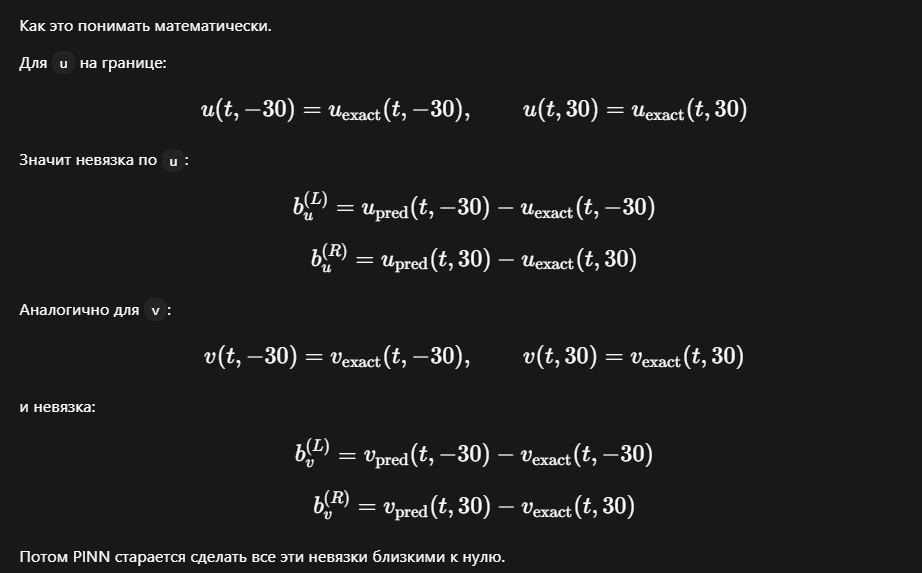

In [ ]:
def residuals_from_fields(fields):
    """
    fields ????????:
    u, v, u_t, u_x, u_xx, v_t, v_x, v_xx
    """

    r_u = fields['u_t'] + us * fields['u'] * fields['u_x'] + fields['v'] + fields['v_xx']
    r_v = fields['v'] - fields['u_xx']

    return {
        'r_u': r_u,
        'r_v': r_v,
    }


def predict_uv(model_like, variant_name, X):
    X = X.to(dtype=DTYPE, device=DEVICE)
    if variant_name == 'two_models':
        u_pred = model_like['u'](X)
        v_pred = model_like['v'](X)
    else:
        y_pred = model_like(X)
        u_pred, v_pred = split_uv(y_pred)
    return u_pred, v_pred


def plot_training_snapshot(model_like, variant_name, step, plot_times=None, num_x=PLOT_NUM_X):
    if plot_times is None:
        plot_times = [tmin, 0.5 * (tmin + tmax), tmax]

    x_plot = torch.linspace(xmin, xmax, num_x, dtype=DTYPE, device=DEVICE).reshape(-1, 1)
    x_np = x_plot.detach().cpu().numpy().squeeze()

    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)
    fig.suptitle(f'{variant_name}: approximation at step {step}', fontsize=14)

    for col, t_value in enumerate(plot_times):
        t_scalar = float(t_value)
        t_plot = torch.full((num_x, 1), t_scalar, dtype=DTYPE, device=DEVICE)
        X_plot = stack_tx(t_plot, x_plot)

        with torch.no_grad():
            u_pred, v_pred = predict_uv(model_like, variant_name, X_plot)
        u_true = u_exact(t_plot, x_plot)
        v_true = v_exact(t_plot, x_plot)

        u_pred_np = u_pred.detach().cpu().numpy().squeeze()
        v_pred_np = v_pred.detach().cpu().numpy().squeeze()
        u_true_np = u_true.detach().cpu().numpy().squeeze()
        v_true_np = v_true.detach().cpu().numpy().squeeze()

        mae_u = float(np.mean(np.abs(u_pred_np - u_true_np)))
        mae_v = float(np.mean(np.abs(v_pred_np - v_true_np)))

        axes[0, col].plot(x_np, u_true_np, label='exact', lw=2)
        axes[0, col].plot(x_np, u_pred_np, '--', label='pred', lw=2)
        axes[0, col].set_title(f't = {t_scalar:.2f}, MAE(u) = {mae_u:.2e}')
        axes[0, col].set_ylabel('u(t, x)')

        axes[1, col].plot(x_np, v_true_np, label='exact', lw=2)
        axes[1, col].plot(x_np, v_pred_np, '--', label='pred', lw=2)
        axes[1, col].set_title(f't = {t_scalar:.2f}, MAE(v) = {mae_v:.2e}')
        axes[1, col].set_xlabel('x')
        axes[1, col].set_ylabel('v(t, x)')

    axes[0, 0].legend()
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub):
    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    u_lb_pred, v_lb_pred = predict_uv(model_like, variant_name, X_lb)
    u_ub_pred, v_ub_pred = predict_uv(model_like, variant_name, X_ub)

    u_lb_exact = u_exact(t_lb, x_lb).detach()
    u_ub_exact = u_exact(t_ub, x_ub).detach()
    v_lb_exact = v_exact(t_lb, x_lb).detach()
    v_ub_exact = v_exact(t_ub, x_ub).detach()

    b_u = torch.cat([
        u_lb_pred - u_lb_exact,
        u_ub_pred - u_ub_exact,
    ], dim=0)

    b_v = torch.cat([
        v_lb_pred - v_lb_exact,
        v_ub_pred - v_ub_exact,
    ], dim=0)

    return {
        'b_u': b_u,
        'b_v': b_v,
    }


## 11. Функция потерь для каждого варианта

In [ ]:
def select_fields(model_like, variant_name, X):
    if variant_name == 'two_output':
        return derivatives_two_output_model(model_like, X)
    if variant_name == 'two_models':
        return derivatives_two_models(model_like['u'], model_like['v'], X)
    if variant_name == 'shared_trunk':
        return derivatives_two_output_model(model_like, X)
    raise ValueError(f'Unknown variant_name: {variant_name}')


def initial_condition_loss(model_like, variant_name, X_0, u_0, v_0):
    fields_0 = select_fields(model_like, variant_name, X_0)
    phi_0_u = mse(fields_0['u'] - u_0)
    phi_0_v = mse(fields_0['v'] - v_0)
    return {
        'phi_0_u': phi_0_u,
        'phi_0_v': phi_0_v,
        'phi_0': phi_0_u + phi_0_v,
    }


def compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub):
    fields_r = select_fields(model_like, variant_name, X_r)
    residuals = residuals_from_fields(fields_r)
    bc = boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub)
    ic = initial_condition_loss(model_like, variant_name, X_0, u_0, v_0)

    phi_r = torch.stack([mse(val) for val in residuals.values()]).sum()
    phi_b = torch.stack([mse(val) for val in bc.values()]).sum()
    phi_0 = ic['phi_0']

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0

    metrics = {
        'total': total_loss,
        'phi_r': phi_r,
        'phi_b': phi_b,
        'phi_0': phi_0,
    }
    metrics.update(ic)
    return total_loss, metrics


## 12. Шаг обучения и цикл тренировки

Здесь один и тот же каркас можно использовать для всех трех вариантов.

In [ ]:
def trainable_parameters_for_variant(model_like, variant_name):
    if variant_name == 'two_models':
        return itertools.chain(model_like['u'].parameters(), model_like['v'].parameters())
    return model_like.parameters()


def set_variant_mode(model_like, variant_name, training=True):
    if variant_name == 'two_models':
        model_like['u'].train(training)
        model_like['v'].train(training)
    else:
        model_like.train(training)


def train_step(model_like, optimizer, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub):
    set_variant_mode(model_like, variant_name, training=True)
    optimizer.zero_grad(set_to_none=True)
    total_loss, metrics = compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub)
    total_loss.backward()
    optimizer.step()
    return {name: value.detach() for name, value in metrics.items()}


def run_training(model_like, optimizer, variant_name, num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY, plot_times=None, plot_num_x=PLOT_NUM_X):
    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    print(f'[{variant_name}] training device: {DEVICE}')
    t0 = time()
    for step in range(num_steps + 1):
        metrics = train_step(model_like, optimizer, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub)

        history['step'].append(step)
        history['total'].append(float(metrics['total'].item()))
        history['phi_r'].append(float(metrics['phi_r'].item()))
        history['phi_b'].append(float(metrics['phi_b'].item()))
        history['phi_0'].append(float(metrics['phi_0'].item()))

        if step % print_every == 0:
            print(f"[{variant_name}] step={step:05d} total={float(metrics['total'].item()):.6e}")

        if plot_every and step > 0 and step % plot_every == 0:
            plot_training_snapshot(model_like, variant_name, step, plot_times=plot_times, num_x=plot_num_x)

    print(f'[{variant_name}] elapsed: {time() - t0:.2f} sec')
    return history


## 13. Инициализация трех подходов

In [ ]:
two_output_model = TwoOutputPINN(
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    hidden_dim=HIDDEN_DIM,
    num_fourier=NUM_FOURIER,
    activation=ACTIVATION,
).to(device=DEVICE, dtype=DTYPE)
two_output_optim = torch.optim.Adam(two_output_model.parameters(), lr=LEARNING_RATE)

two_models = {
    'u': SingleOutputPINN(
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
        name='model_u',
    ).to(device=DEVICE, dtype=DTYPE),
    'v': SingleOutputPINN(
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
        name='model_v',
    ).to(device=DEVICE, dtype=DTYPE),
}
two_models_optim = torch.optim.Adam(
    itertools.chain(two_models['u'].parameters(), two_models['v'].parameters()),
    lr=LEARNING_RATE,
)

shared_trunk_model = SharedTrunkPINN(
    num_shared_layers=NUM_SHARED_LAYERS,
    hidden_dim=HIDDEN_DIM,
    num_fourier=NUM_FOURIER,
    activation=ACTIVATION,
).to(device=DEVICE, dtype=DTYPE)
shared_trunk_optim = torch.optim.Adam(shared_trunk_model.parameters(), lr=LEARNING_RATE)


## 14. Запуск экспериментов

Снимите комментарии после того, как заполните `u_exact`, `v_exact`, `residuals_from_fields` и `boundary_residuals_from_exact`.

In [ ]:
history_two_output = run_training(
    two_output_model,
    two_output_optim,
    'two_output',
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY,
    plot_every=PLOT_EVERY,
)
history_two_models = run_training(
    two_models,
    two_models_optim,
    'two_models',
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY,
    plot_every=PLOT_EVERY,
)
history_shared_trunk = run_training(
    shared_trunk_model,
    shared_trunk_optim,
    'shared_trunk',
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY,
    plot_every=PLOT_EVERY,
)


[two_output] training device: cpu
[two_output] step=00000 total=3.257659e-01
[two_output] step=00100 total=5.575469e-03
[two_output] step=00200 total=4.986678e-03
[two_output] step=00300 total=4.738669e-03
[two_output] step=00400 total=4.519587e-03


## 15. Сравнение графиков потерь

In [ ]:
def load_history_from_notebook(nb_path='start.ipynb'):
    nb_path = Path(nb_path)
    with nb_path.open('r', encoding='utf-8') as f:
        nb = json.load(f)

    pattern = re.compile(
        r"It\s+(\d+):\s+total=([0-9.eE+-]+),\s+phi_r=([0-9.eE+-]+),\s+phi_b=([0-9.eE+-]+),\s+phi_0=([0-9.eE+-]+)"
    )

    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            if output.get('output_type') != 'stream':
                continue

            text = output.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)

            for match in pattern.finditer(text):
                history['step'].append(int(match.group(1)))
                history['total'].append(float(match.group(2)))
                history['phi_r'].append(float(match.group(3)))
                history['phi_b'].append(float(match.group(4)))
                history['phi_0'].append(float(match.group(5)))

    if not history['step']:
        raise ValueError(f'Не удалось извлечь history из {nb_path}')

    return history


def plot_histories(histories, stage1_history=None, stage1_label='stage1'):
    plt.figure(figsize=(9, 4))

    if stage1_history is not None:
        plt.semilogy(stage1_history['step'], stage1_history['total'], '--', lw=2, label=stage1_label)

    for label, history in histories.items():
        plt.semilogy(history['step'], history['total'], label=label)

    plt.xlabel('iteration')
    plt.ylabel('total loss')
    plt.title('Сравнение сходимости: этап 1 и три подхода этапа 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_history(history, label):
    total = np.array(history['total'])
    steps = np.array(history['step'])
    best_idx = int(np.argmin(total))

    return {
        'label': label,
        'best_step': int(steps[best_idx]),
        'best_total': float(total[best_idx]),
        'final_total': float(total[-1]),
    }


def print_history_summary(histories, stage1_history=None, stage1_label='stage1'):
    rows = []
    if stage1_history is not None:
        rows.append(summarize_history(stage1_history, stage1_label))

    for label, history in histories.items():
        rows.append(summarize_history(history, label))

    for row in rows:
        print(
            f"{row['label']}: best_step={row['best_step']}, "
            f"best_total={row['best_total']:.6e}, final_total={row['final_total']:.6e}"
        )


# Пример использования:
# stage1_history = load_history_from_notebook('start.ipynb')
# plot_histories({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')
# print_history_summary({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')


## 16. Сравнение с этапом 1

По ТЗ нужно сравнить график сходимости этапа 2 с результатами этапа 1.

В этом шаблоне это делается так:

1. функция `load_history_from_notebook('start.ipynb')` читает сохраненный лог обучения из ноутбука первого этапа;
2. `plot_histories(..., stage1_history=...)` накладывает кривую этапа 1 на графики этапа 2;
3. `print_history_summary(...)` печатает краткую сводку по лучшему и финальному лоссу.

In [ ]:
stage1_history = load_history_from_notebook('start.ipynb')
plot_histories({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')
print_history_summary({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')


## 17. Шаблон сравнительного анализа

Заполните этот блок после запуска всех экспериментов.

**Сравнение с этапом 1**

- Лучшее значение функции потерь на этапе 1: `...`
- Лучшее значение функции потерь на этапе 2 для каждой архитектуры: `...`
- Какая архитектура приблизилась к решению быстрее относительно этапа 1: `...`
- Есть ли более сильные колебания лосса по сравнению с этапом 1: `...`

**Сравнение трёх подходов этапа 2**

- Одна сеть с двумя выходами: сильные стороны `...`, слабые стороны `...`
- Две отдельные сети: сильные стороны `...`, слабые стороны `...`
- Shared trunk + две головы: сильные стороны `...`, слабые стороны `...`

**Итоговый вывод**

- Наиболее устойчивый подход: `...`
- Наиболее точный подход по итоговому лоссу: `...`
- Какой подход вы считаете наиболее удачным и почему: `...`


## 18. Мини-чеклист перед запуском

Что нужно заполнить вручную:

1. `u_exact(t, x)`
2. `v_exact(t, x)`
3. `residuals_from_fields(fields)`
4. `boundary_residuals_from_exact(...)`
5. при необходимости коэффициенты уравнения
6. число шагов обучения и гиперпараметры

Какие функции у вас уже готовы по именам:

- `TwoOutputPINN`
- `SingleOutputPINN`
- `SharedTrunkPINN`
- `derivatives_two_output_model`
- `derivatives_two_models`
- `compute_total_loss`
- `train_step`
- `run_training`
- `load_history_from_notebook`
- `plot_histories`
- `print_history_summary`

Если захотите, следующий шаг я могу сделать тоже за вас: заполнить сюда формулы именно под вашу систему после подстановки.